In [3]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set()


In [4]:
#Data Load
world_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\23048838 Muna Pun AI\worldwide-aggregate.csv"
)

country_df = pd.read_csv(
    r"C:\Users\Dell\Desktop\23048838 Muna Pun AI\countries-aggregated.csv"
)

world_df["Date"] = pd.to_datetime(world_df["Date"])
country_df["Date"] = pd.to_datetime(country_df["Date"])

# SHOW OUTPUT (IMPORTANT)
display(world_df.head())
display(country_df.head())


,Date,Confirmed,Recovered,Deaths,Increase rate
0,2020-01-22,557,30,17,NaN
1,2020-01-23,657,32,18,17.953321
2,2020-01-24,944,39,26,43.683409
3,2020-01-25,1437,42,42,52.224576
4,2020-01-26,2120,56,56,47.529576


,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


In [5]:
#Dataset Overview & Preview
overview_df = pd.DataFrame({
    "Dataset": ["Worldwide Aggregate", "Countries Aggregated"],
    "Rows": [world_df.shape[0], country_df.shape[0]],
    "Columns": [world_df.shape[1], country_df.shape[1]]
})
display(overview_df)

display(world_df.head())
display(country_df.head())


,Dataset,Rows,Columns
0,Worldwide Aggregate,816,5
1,Countries Aggregated,161568,5


,Date,Confirmed,Recovered,Deaths,Increase rate
0,2020-01-22,557,30,17,NaN
1,2020-01-23,657,32,18,17.953321
2,2020-01-24,944,39,26,43.683409
3,2020-01-25,1437,42,42,52.224576
4,2020-01-26,2120,56,56,47.529576


,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


In [6]:
#Aggregate & Merge Datasets
country_agg = country_df.groupby("Date").agg({
    "Confirmed": "sum",
    "Deaths": "sum",
    "Recovered": "sum"
}).reset_index()

country_agg.columns = [
    "Date", "Country_Confirmed", "Country_Deaths", "Country_Recovered"
]

merged_df = pd.merge(world_df, country_agg, on="Date", how="inner")
merged_df = merged_df.sort_values("Date").reset_index(drop=True)

display(merged_df.head())


,Date,Confirmed,Recovered,Deaths,Increase rate,Country_Confirmed,Country_Deaths,Country_Recovered
0,2020-01-22,557,30,17,NaN,557,17,30
1,2020-01-23,657,32,18,17.953321,657,18,32
2,2020-01-24,944,39,26,43.683409,944,26,39
3,2020-01-25,1437,42,42,52.224576,1437,42,42
4,2020-01-26,2120,56,56,47.529576,2120,56,56


In [7]:
#Missing Values Check
missing_df = merged_df.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing Values"]
display(missing_df)


,Column,Missing Values
0,Date,0
1,Confirmed,0
2,Recovered,0
3,Deaths,0
4,Increase rate,1
5,Country_Confirmed,0
6,Country_Deaths,0
7,Country_Recovered,0


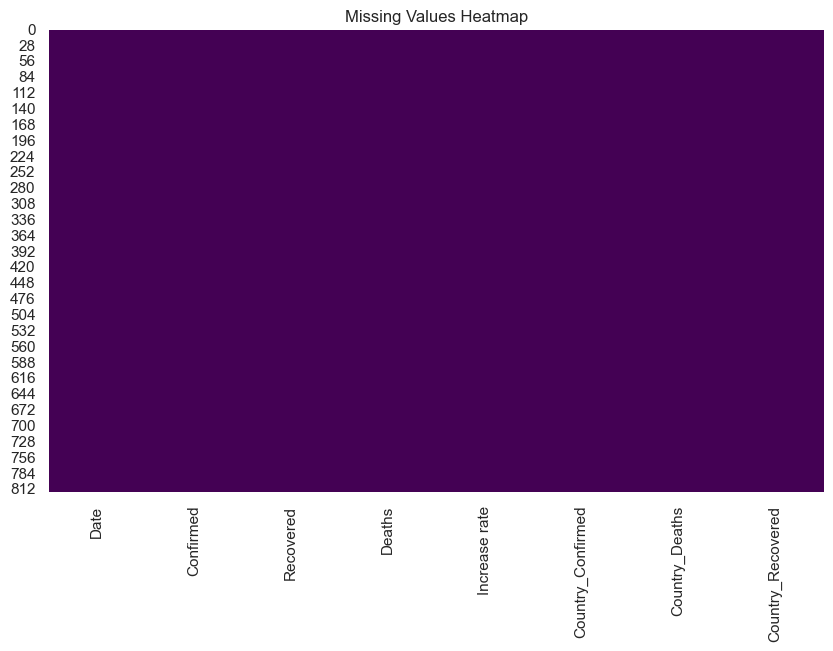

In [8]:
#Missing Values Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(merged_df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


In [9]:
#Handle Missing Values & Duplicates
merged_df.ffill(inplace=True)
merged_df.drop_duplicates(inplace=True)
merged_df.reset_index(drop=True, inplace=True)

display(pd.DataFrame({
    "Rows After Cleaning": [merged_df.shape[0]],
    "Columns After Cleaning": [merged_df.shape[1]]
}))


,Rows After Cleaning,Columns After Cleaning
0,816,8


In [10]:
#Feature Engineering
merged_df["Lag_1"] = merged_df["Confirmed"].shift(1)
merged_df["Lag_2"] = merged_df["Confirmed"].shift(2)

merged_df["Rolling_3"] = merged_df["Confirmed"].rolling(3).mean()
merged_df["Rolling_7"] = merged_df["Confirmed"].rolling(7).mean()

merged_df["Growth_Rate"] = merged_df["Confirmed"].pct_change()

merged_df.dropna(inplace=True)
merged_df.reset_index(drop=True, inplace=True)

display(merged_df.head())


,Date,Confirmed,Recovered,Deaths,Increase rate,Country_Confirmed,Country_Deaths,Country_Recovered,Lag_1,Lag_2,Rolling_3,Rolling_7,Growth_Rate
0,2020-01-28,5580,108,131,90.508706,5580,131,108,2929.0,2120.0,3543.000000,2032.000000,0.905087
1,2020-01-29,6169,127,133,10.555556,6169,133,127,5580.0,2929.0,4892.666667,2833.714286,0.105556
2,2020-01-30,8237,145,171,33.522451,8237,171,145,6169.0,5580.0,6662.000000,3916.571429,0.335225
3,2020-01-31,9927,225,213,20.517179,9927,213,225,8237.0,6169.0,8111.000000,5199.857143,0.205172
4,2020-02-01,12038,287,259,21.265236,12038,259,287,9927.0,8237.0,10067.333333,6714.285714,0.212652


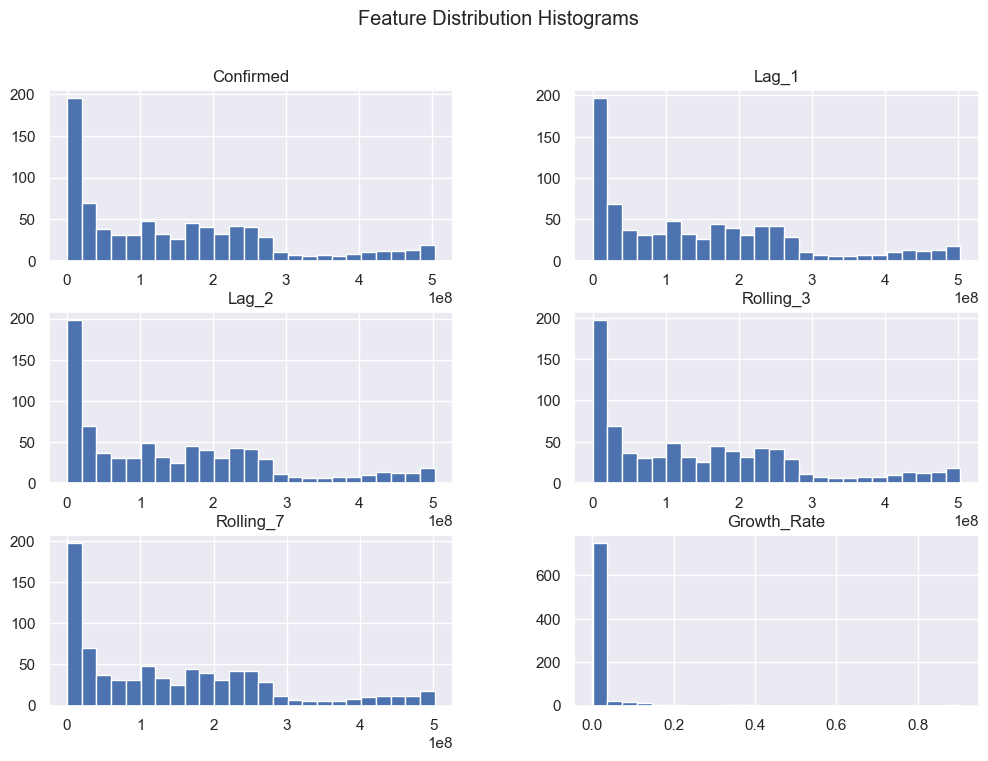

In [11]:
#Feature Distribution
merged_df[
    ["Confirmed", "Lag_1", "Lag_2", "Rolling_3", "Rolling_7", "Growth_Rate"]
].hist(bins=25, figsize=(12, 8))
plt.suptitle("Feature Distribution Histograms")
plt.show()


,Confirmed,Lag_1,Lag_2,Rolling_3,Rolling_7,Growth_Rate,Country_Confirmed,Country_Deaths,Country_Recovered
Confirmed,1.000000,0.999994,0.999977,0.999994,0.999952,-0.274677,1.000000,0.956423,-0.077014
Lag_1,0.999994,1.000000,0.999994,1.000000,0.999979,-0.274702,0.999994,0.956555,-0.076730
Lag_2,0.999977,0.999994,1.000000,0.999994,0.999994,-0.274719,0.999977,0.956695,-0.076444
Rolling_3,0.999994,1.000000,0.999994,1.000000,0.999979,-0.274700,0.999994,0.956561,-0.076730
Rolling_7,0.999952,0.999979,0.999994,0.999979,1.000000,-0.274730,0.999952,0.956877,-0.076169
Growth_Rate,-0.274677,-0.274702,-0.274719,-0.274700,-0.274730,1.000000,-0.274677,-0.339049,-0.176148
Country_Confirmed,1.000000,0.999994,0.999977,0.999994,0.999952,-0.274677,1.000000,0.956423,-0.077014
Country_Deaths,0.956423,0.956555,0.956695,0.956561,0.956877,-0.339049,0.956423,1.000000,0.048760
Country_Recovered,-0.077014,-0.076730,-0.076444,-0.076730,-0.076169,-0.176148,-0.077014,0.048760,1.000000


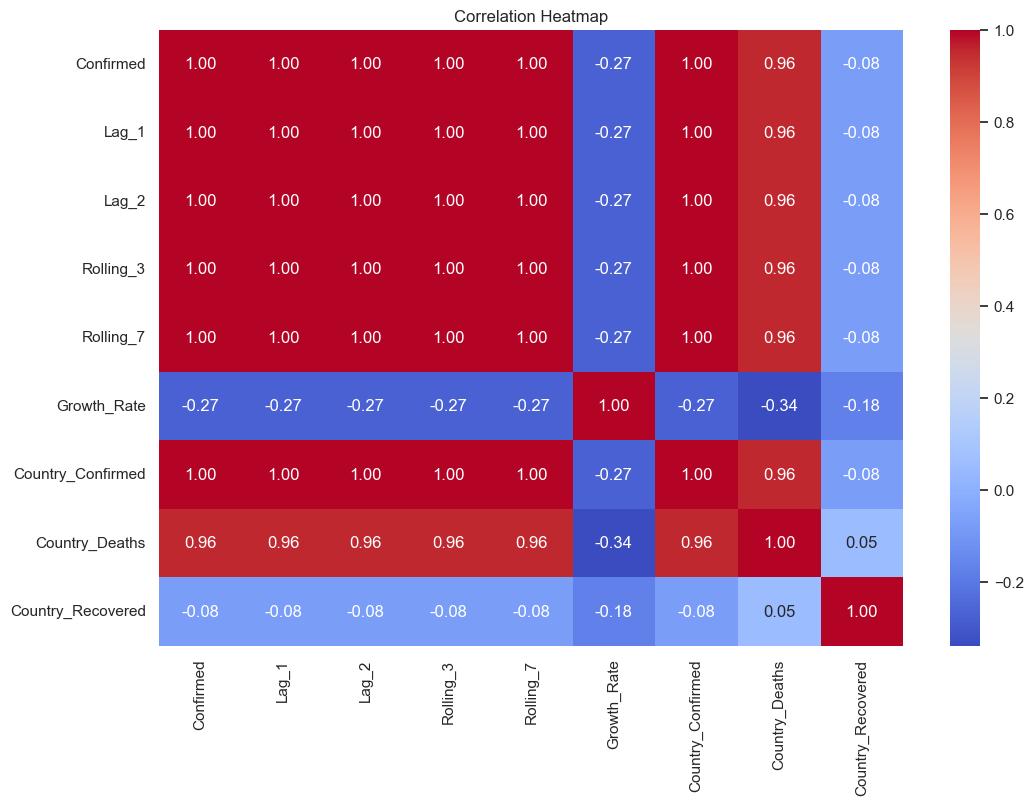

In [12]:
#Correlation Heatmap
corr_features = [
    "Confirmed", "Lag_1", "Lag_2",
    "Rolling_3", "Rolling_7", "Growth_Rate",
    "Country_Confirmed", "Country_Deaths", "Country_Recovered"
]

corr_df = merged_df[corr_features].corr()
display(corr_df)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [13]:
#Feature Selection & Train-Test Split
features = [
    "Lag_1", "Lag_2", "Rolling_3", "Rolling_7",
    "Growth_Rate", "Country_Confirmed",
    "Country_Deaths", "Country_Recovered"
]

X = merged_df[features]
y = merged_df["Confirmed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

display(pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
}))


,Dataset,Shape
0,X_train,"(648, 8)"
1,X_test,"(162, 8)"
2,y_train,"(648,)"
3,y_test,"(162,)"


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import time
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=100, random_state=42
    )
}

results = []
predictions = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # ⭐ Save trained models for future prediction
    if name == "Linear Regression":
        lr_model = model
    elif name == "Random Forest Regression":
        rf_model = model

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (%)": np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
        "R² Score": r2_score(y_test, y_pred),
        "Training Time (seconds)": train_time
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,MAE,RMSE,MAPE (%),R² Score,Training Time (seconds)
0,Linear Regression,2.354751e-07,2.609056e-07,6.104283e-14,1.000000,0.073305
1,Random Forest Regression,1.152390e+08,1.453843e+08,2.734490e+01,-1.690206,1.239027


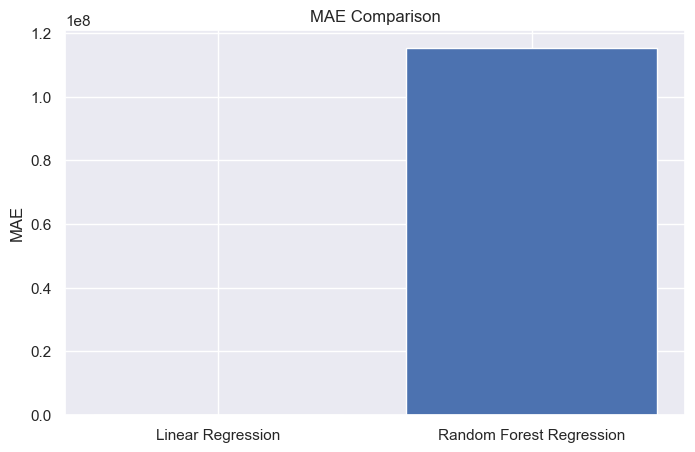

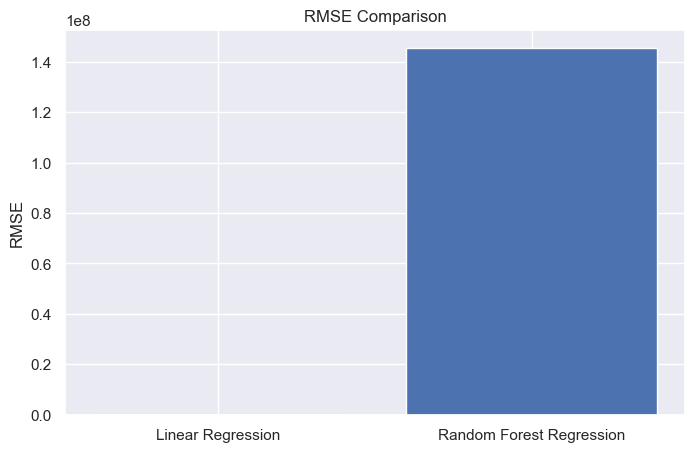

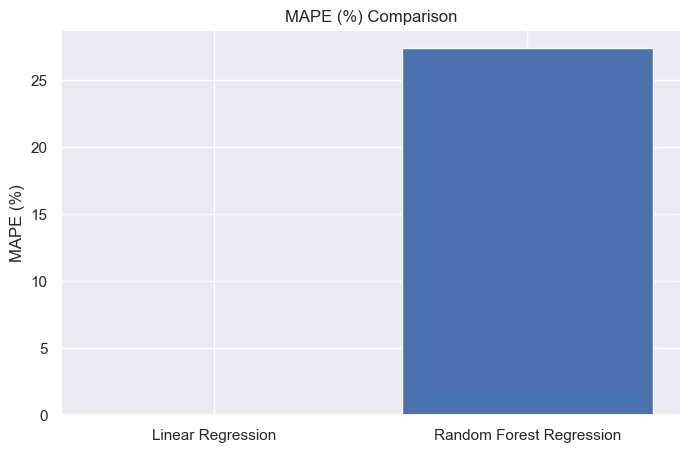

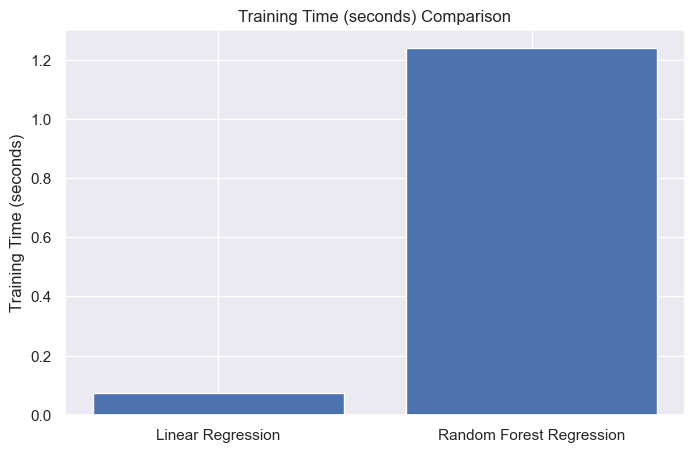

In [15]:
#Accuracy & Training Time Comparison
metrics = ["MAE", "RMSE", "MAPE (%)", "Training Time (seconds)"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.show()


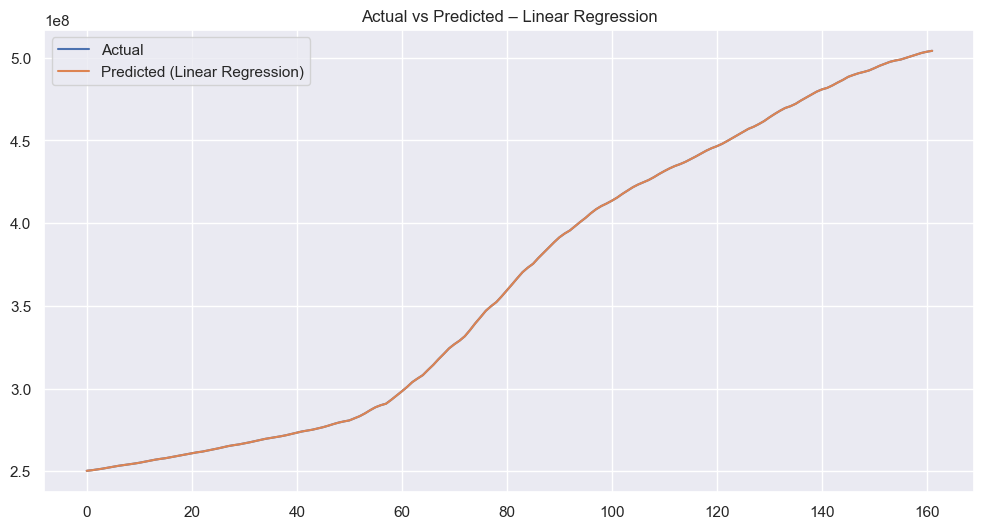

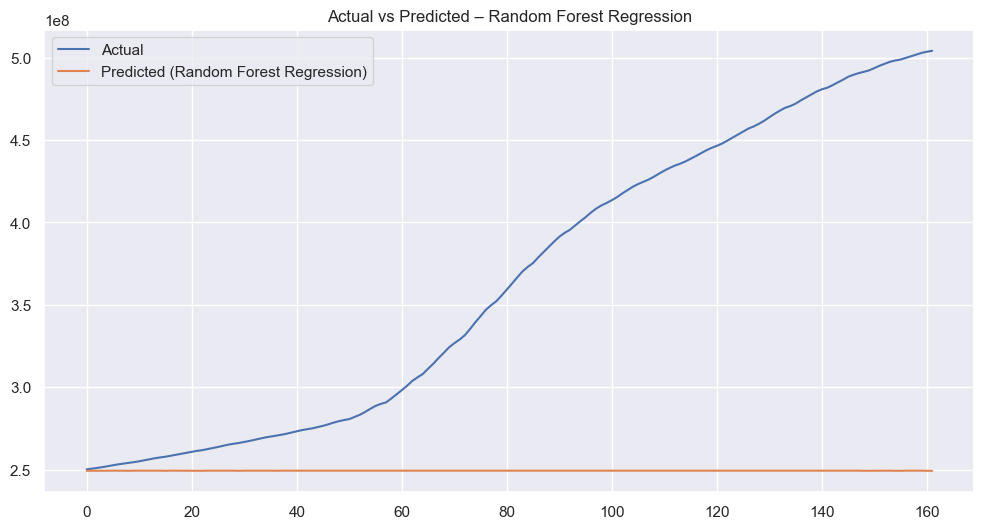

In [16]:
#Actual vs Predicted
for name, y_pred in predictions.items():
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.values, label="Actual")
    plt.plot(y_pred, label=f"Predicted ({name})")
    plt.title(f"Actual vs Predicted – {name}")
    plt.legend()
    plt.show()


In [17]:
#Best Model Selection
best_model_name = comparison_df.loc[
    comparison_df["RMSE"].idxmin(), "Model"
]
best_model = models[best_model_name]

display(pd.DataFrame({
    "Selection Rule": ["Lowest RMSE"],
    "Best Model": [best_model_name]
}))


,Selection Rule,Best Model
0,Lowest RMSE,Linear Regression


,Feature,Coefficient
0,Lag_1,-8.333333e-02
1,Lag_2,-8.333333e-02
2,Rolling_3,2.500000e-01
3,Rolling_7,6.042857e-15
4,Growth_Rate,-3.362979e-07
5,Country_Confirmed,9.166667e-01
6,Country_Deaths,-4.807822e-14
7,Country_Recovered,3.129269e-16


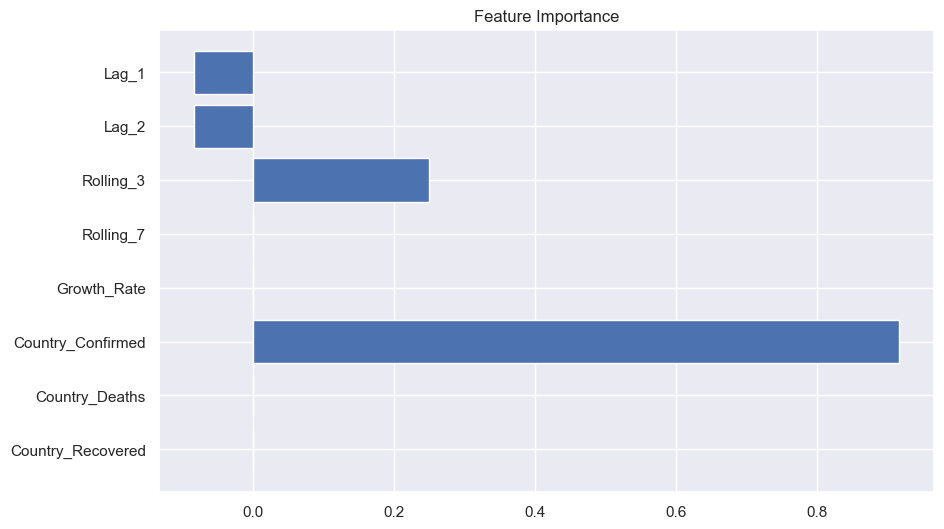

In [18]:
#Feature Importance
if best_model_name == "Linear Regression":
    importance_df = pd.DataFrame({
        "Feature": features,
        "Coefficient": best_model.coef_
    })
else:
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    })

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df.iloc[:, 1])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()


In [19]:
#Final Prediction Output
merged_df["Predicted_Confirmed"] = best_model.predict(X)
display(merged_df[["Date", "Confirmed", "Predicted_Confirmed"]].head())


,Date,Confirmed,Predicted_Confirmed
0,2020-01-28,5580,5580.0
1,2020-01-29,6169,6169.0
2,2020-01-30,8237,8237.0
3,2020-01-31,9927,9927.0
4,2020-02-01,12038,12038.0


,Date,Predicted_Confirmed
809,2022-04-16,504155459.0
808,2022-04-15,503606396.0
807,2022-04-14,502892186.0
806,2022-04-13,501920234.0
805,2022-04-12,500880363.0
804,2022-04-11,499843502.0
803,2022-04-10,498868313.0
802,2022-04-09,498299996.0
801,2022-04-08,497531675.0
800,2022-04-07,496338419.0


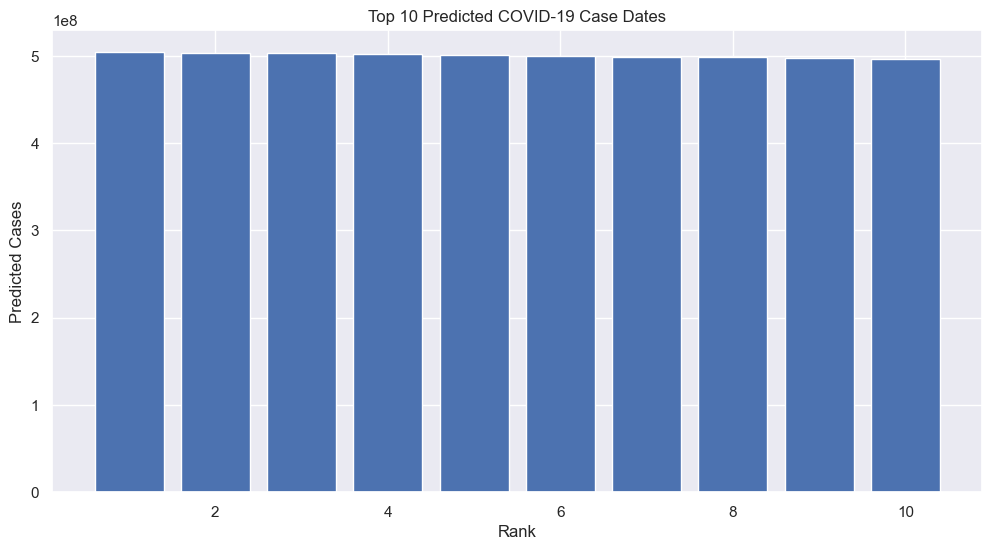

In [20]:
#Top-10 Prediction Visualization
top_10 = merged_df.sort_values(
    by="Predicted_Confirmed", ascending=False
).head(10)

display(top_10[["Date", "Predicted_Confirmed"]])

plt.figure(figsize=(12, 6))
plt.bar(range(1, 11), top_10["Predicted_Confirmed"])
plt.title("Top 10 Predicted COVID-19 Case Dates")
plt.xlabel("Rank")
plt.ylabel("Predicted Cases")
plt.show()


In [21]:
import numpy as np
import pandas as pd

def predict_future():
    print("--- User Input for Future Prediction ---")
    print("Please provide the required data to predict the Confirmed Cases for the next day (T).")

    try:
        # 1. Historical Data
        print("\n1. Historical Data")
        days_input = input(
            "Enter Confirmed Cases for the last 7 days (Day T-7 to Day T-1), separated by commas:\n"
            "Example: 1000, 1100, 1200, 1300, 1400, 1500, 1600\n> "
        )

        last_7_days = [float(x.strip()) for x in days_input.split(",")]

        if len(last_7_days) != 7:
            print(f"Error: Expected 7 values, got {len(last_7_days)}.")
            return

        # Feature Engineering
        lag_1 = last_7_days[-1]
        lag_2 = last_7_days[-2]
        rolling_3 = np.mean(last_7_days[-3:])
        rolling_7 = np.mean(last_7_days)
        growth_rate = (lag_1 - lag_2) / lag_2 if lag_2 != 0 else 0

        # 2. Current Totals
        print("\n2. Current Totals")
        country_confirmed = float(
            input(f"Enter Total Confirmed Cases so far (press Enter to use {lag_1}): ") or lag_1
        )
        country_deaths = float(input("Enter Total Deaths so far: "))
        country_recovered = float(input("Enter Total Recovered so far: "))

        # Prepare input features
        input_features = pd.DataFrame([{
            'Lag_1': lag_1,
            'Lag_2': lag_2,
            'Rolling_3': rolling_3,
            'Rolling_7': rolling_7,
            'Growth_Rate': growth_rate,
            'Country_Confirmed': country_confirmed,
            'Country_Deaths': country_deaths,
            'Country_Recovered': country_recovered
        }])

        print("\nPrepared Features:")
        display(input_features)

        # Predictions
        print("\n--- Prediction Results ---")

        if 'lr_model' in globals():
            lr_pred = lr_model.predict(input_features)[0]
            print(f"Linear Regression Prediction: {int(lr_pred)} cases")
        else:
            print("Linear Regression model not found.")

        if 'rf_model' in globals():
            rf_pred = rf_model.predict(input_features)[0]
            print(f"Random Forest Prediction: {int(rf_pred)} cases")
        else:
            print("Random Forest model not found.")

    except ValueError:
        print("Invalid input. Please enter numeric values only.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Run the prediction tool
predict_future()


--- User Input for Future Prediction ---
Please provide the required data to predict the Confirmed Cases for the next day (T).

1. Historical Data


Enter Confirmed Cases for the last 7 days (Day T-7 to Day T-1), separated by commas:
Example: 1000, 1100, 1200, 1300, 1400, 1500, 1600
>  1000, 1100, 1200, 1300, 1400, 1500, 1600



2. Current Totals


Enter Total Confirmed Cases so far (press Enter to use 1600.0):  4545
Enter Total Deaths so far:  4545
Enter Total Recovered so far:  454



Prepared Features:


,Lag_1,Lag_2,Rolling_3,Rolling_7,Growth_Rate,Country_Confirmed,Country_Deaths,Country_Recovered
0,1600.0,1500.0,1500.0,1300.0,0.066667,4545.0,4545.0,454.0



--- Prediction Results ---
Linear Regression Prediction: 4282 cases
Random Forest Prediction: 28218 cases
